In [1]:
from astropy.table import Table
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import colors
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()
params = {'figure.labelsize': 'x-large',
          'figure.titlesize': 'x-large',
          'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large'}
pylab.rcParams.update(params)

In [ ]:
os.chdir('(#path to#)asas-sn-cnn/plots/files/testing_csvs_section5')

In [4]:
sim_input_log6 = "simulation_input_30_log6.csv"
cnn_periodsl6 = pd.read_csv(sim_input_log6, header=0, index_col="simulation_number").sort_index().rename(columns={'period':'true_period'})
cnn_periodsl6.index.names = ['sim_id']
cnn_periods_test_log6 = cnn_periodsl6[900000:]

sim_input_log5 = "simulation_input_30_log5.csv"
cnn_periodsl5 = pd.read_csv(sim_input_log5, header=0, index_col="simulation_number").sort_index().rename(columns={'period':'true_period'})
cnn_periodsl5.index.names = ['sim_id']
cnn_periods_test_log5 = cnn_periodsl5[188662:]

In [5]:
table3_row1 = pd.read_csv("6_clump_nor_norm_nan_all/asassn_clump_0_predictions.csv", header=0).sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row2 = pd.read_csv("6_milliquas_yesr_norm_nan_all/asassn_g_0_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row3 = pd.read_csv("5_milliquas_yesr_norm_nan_all/asassn_g_0_predictions.csv", header=0)[188662:].sort_index().join(cnn_periodsl5, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row4 = pd.read_csv("5_milliquas_nor_norm_nan_all/asassn_g_0_predictions.csv", header=0)[188662:].sort_index().join(cnn_periodsl5, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row5 = pd.read_csv("6_milliquas_yesr_norm_min_all/asassn_g_0_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row6 = pd.read_csv("6_milliquas_yesr_10x_nan_all/asassn_g_0_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")

table3_row7 = pd.read_csv("6_milliquas_yesr_norm_nan_all/asassn_g_1_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row8 = pd.read_csv("6_milliquas_yesr_norm_nan_all/asassn_g_2_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row9 = pd.read_csv("6_milliquas_yesr_norm_nan_all/asassn_g_3_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")

table3_row10 = pd.read_csv("6_clump_nor_norm_nan_all/asassn_clump_1_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row11 = pd.read_csv("6_clump_nor_norm_nan_all/asassn_clump_2_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row12 = pd.read_csv("6_clump_nor_norm_nan_all/asassn_clump_3_predictions.csv", header=0)[900000:].sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")

In [6]:
tables = [table3_row1, table3_row10, table3_row11, table3_row12, table3_row2, table3_row7, table3_row8, table3_row9, table3_row3, table3_row4, table3_row5, table3_row6]

In [7]:
def scatter(networks, save=False):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12), layout='compressed')
    ticks_x = [0, 15, 30]
    ticks_y = [15, 30]

    letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    normi = colors.Normalize(0, 0.25)
    for axs, table, letter in zip(axes.flatten(), networks, letters):
        table['frac_err']=table['sigma']/table['period']
        percen = ((len(table.query("frac_err<0.25")) / len(table) * 100))
        strpercen = str(round(percen, 2))

        axs.plot([0, 30], [0, 30], "b",  linewidth=2, label="1:1", rasterized=True)
        axs.plot([0, 30*0.9], [0, 30], "r", linewidth=2, label="90th percentile", rasterized=True)
        axs.plot([0, 30], [0, 30*0.9], "r",  linewidth=2, label="90th percentile", rasterized=True)
        pler = axs.scatter("true_period", "period", data=table.query("frac_err<0.25"), c='frac_err',  cmap='Greys', s=3, rasterized=True)

        axs.set(xlim=(0, 30), ylim=(0, 30))
        axs.set_yticks(ticks = ticks_y, labels=ticks_y, weight='bold')
        axs.set_xticks(ticks = ticks_x, labels=ticks_x, weight='bold')
        axs.text(10, 2.5, f'{letter}: {strpercen}%', fontweight='bold', rasterized=True)
        print(f'{letter}: {strpercen}%')

    fig.supxlabel('True Period [d]', weight='bold')
    fig.supylabel('Predicted Period [d]', weight='bold')
    cbar = fig.colorbar(pler, ax=axes,  norm = normi, orientation='vertical')
    cbar.set_label(label = 'Fractional Error [sigma/period]', weight='bold')
    if(save==True):
        plt.savefig('testplots.pdf', dpi=300)

(a): 19.82%
(b): 21.54%
(c): 21.43%
(d): 21.79%
(e): 3.81%
(f): 4.35%
(g): 4.63%
(h): 4.56%
(i): 0.18%
(j): 0.97%
(k): 0.19%
(l): 2.83%


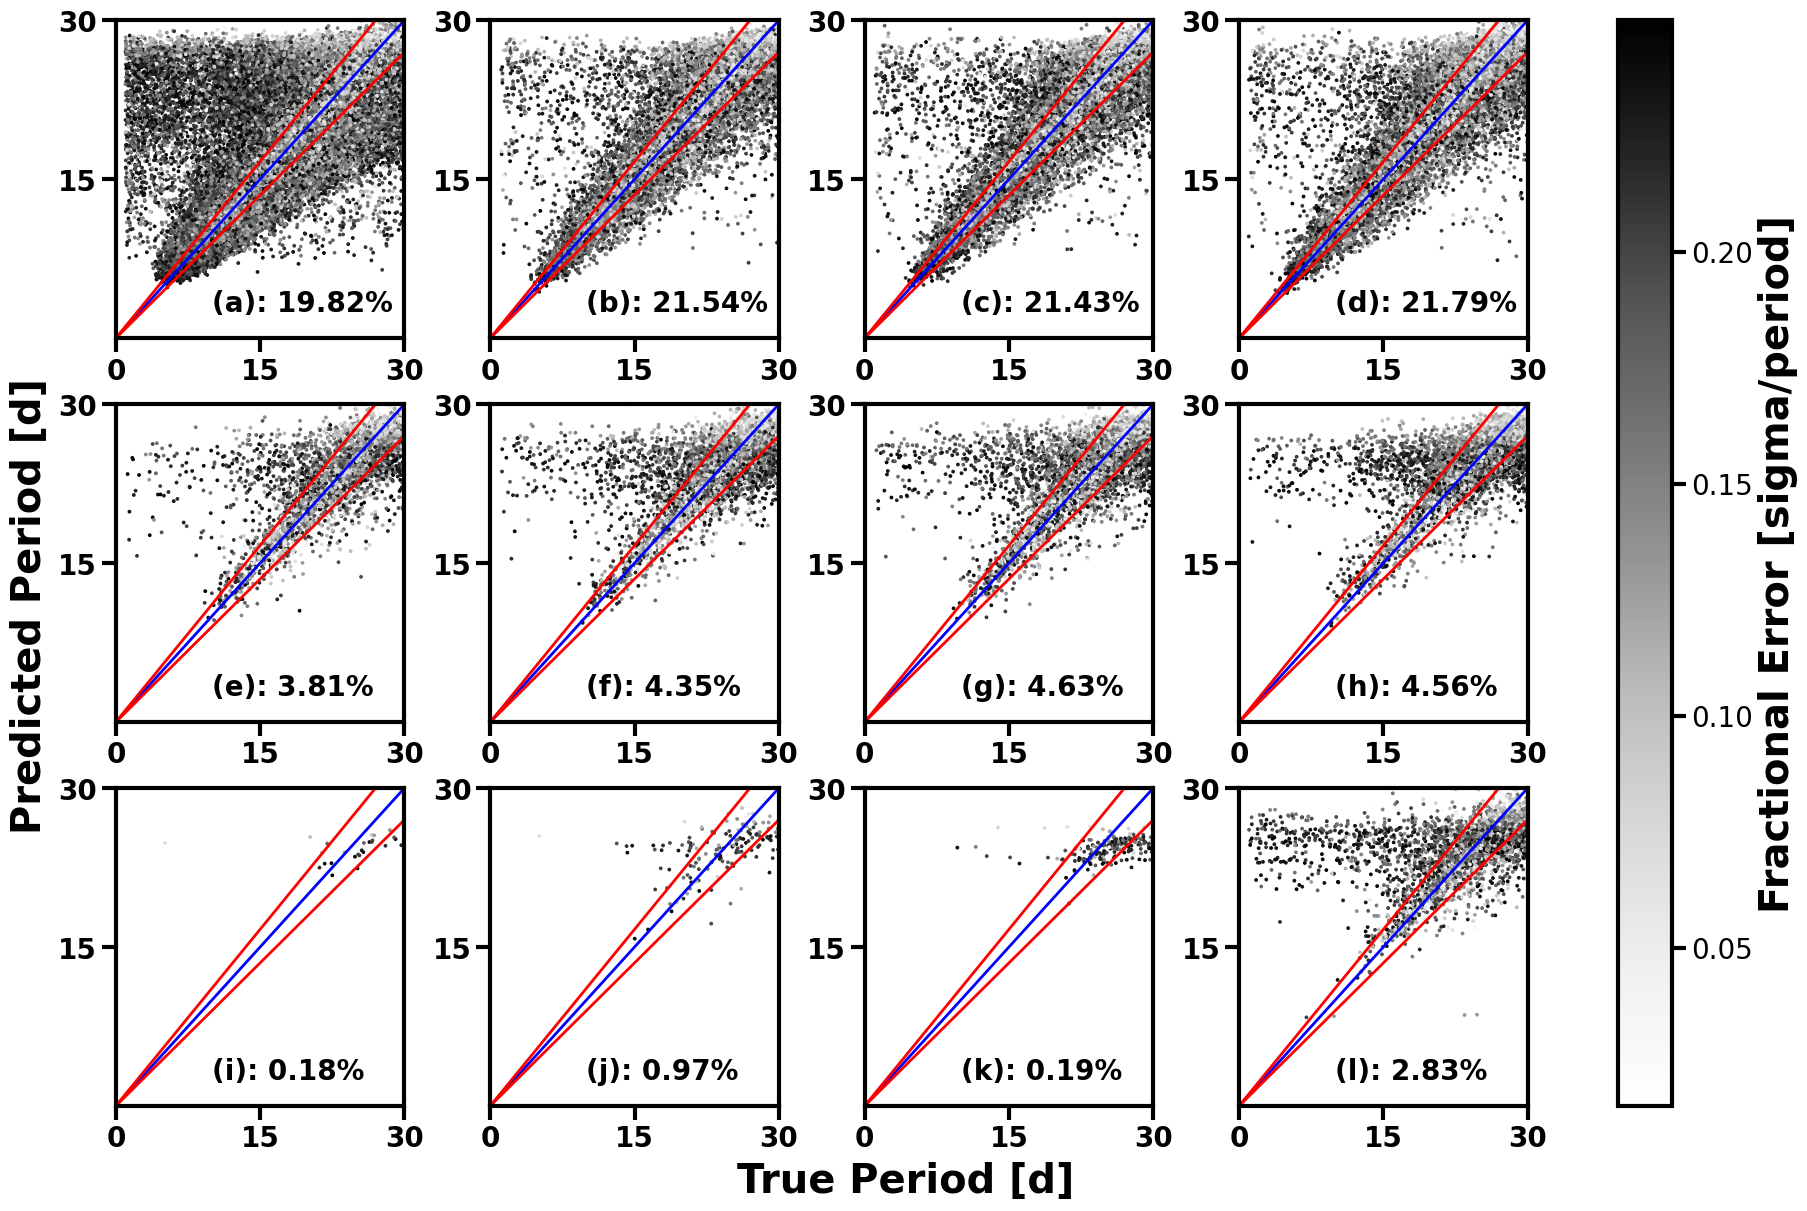

In [8]:
scatter(tables, True)

## (old)  Create a function to make the two figure comparison plots

In [9]:
def scatter_test_bothsamesize(net_top, net_bot, section, save=False):
    # Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 1, figsize=(16, 32))
    tixs2 = [0, 5, 10, 15, 20, 25, 30]
    
    amethodpercen = ((len(net_top.query("sigma<3")) / len(net_top) * 100)) 
    strpercenA = str(round(amethodpercen + 0.0005, 3))
    #strpercenA = str(amethodpercen)
    bmethodpercen = ((len(net_bot.query("sigma<3")) / len(net_bot) * 100))
    if(bmethodpercen==0.0):
        strpercenB = str(0)
    else:
        strpercenB = str(round(bmethodpercen + 0.0005, 3))
    
    if(section=="5.1"):
        axs[0].set_title(f"Training set of $\\bf10^6$: {strpercenA}% Successful Predictions", weight='bold', pad=20)
        axs[1].set_title(f"Training set of $\\bf10^5$: {strpercenB}% Successful Predictions", weight='bold', pad=20)
    if(section=="5.2"):
        axs[0].set_title(f"Non-repeated templates ($\\bf10^5$): {strpercenA}% Successful Predictions", weight='bold', pad=20)
        axs[1].set_title(f"Repeated templates ($\\bf10^5$): {strpercenB}% Successful Predictions", weight='bold', pad=20)
    if(section=="5.3"):
        axs[0].set_title(f"Cubic Nanmask: {strpercenA}% Successful Predictions", weight='bold', pad=20)
        axs[1].set_title(f"Cubic Minmask: {strpercenB}% Successful Predictions", weight='bold', pad=20)
    if(section=="5.4"):
        axs[0].set_title(f"No repeats regular scaling: {strpercenA}% Successful Predictions",weight='bold', pad=20)
        axs[1].set_title(f"Repeats 10x scaling: {strpercenB}% Successful Predictions", weight='bold', pad=20)
    if(section=="5.6"):
        axs[1].set_title(f"Clump Trained ($\\bf10^6$): {strpercenB}% Successful Predictions",weight='bold', pad=20)
        axs[0].set_title(f"Milliquas Trained ($\\bf10^6$): {strpercenA}% Successful Predictions", weight='bold', pad=20)
    
    
    axs[0].scatter("true_period", "period", data=net_top.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
    axs[0].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[0].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[0].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[0].set(xlim=(0, 30), ylim=(0, 30))
    axs[0].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[0].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')
    
    axs[1].scatter("true_period", "period", data=net_bot.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
    axs[1].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[1].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[1].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[1].set(xlim=(0, 30), ylim=(0, 30))
    axs[1].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[1].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')
    
    fig.supxlabel('True Period (days)', weight='bold')
    fig.supylabel('Predicted Period (days)', weight='bold')
    plt.tight_layout()
    if(save==True):
        if(section=="5.1"):
            plt.savefig('millionv200k.pdf', dpi=300)
        elif(section=="5.2"):
            plt.savefig('norepeats.pdf', dpi=300)
        elif(section=="5.3"):
            plt.savefig('cubicnanvsmin.pdf', dpi=300)
        elif(section=="5.4"):
            plt.savefig('scaling.pdf', dpi=300)
        elif(section=="5.6"):
            plt.savefig('clumpvquasar.pdf', dpi=300)
            
    # Show the plots
    plt.show()

## (old) Create a function to make the 4 figure comparison plots

In [10]:
def scatter_test_4(tlnet, trnet, blnet, brnet, section, save=False):
    #Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(32, 32))
    tixs2 = [0, 5, 10, 15, 20, 25, 30]
    
    zeronet = ((len(tlnet.query("sigma<3")) / len(tlnet) * 100)) 
    strpercen0 = str(round(zeronet + 0.0005, 3))
    
    onenet = ((len(trnet.query("sigma<3")) / len(trnet) * 100)) 
    strpercen1 = str(round(onenet + 0.0005, 3))
    
    twoonet = ((len(blnet.query("sigma<3")) / len(blnet) * 100)) 
    strpercen2 = str(round(twoonet + 0.0005, 3))
    
    threenet = ((len(brnet.query("sigma<3")) / len(brnet) * 100)) 
    strpercen3 = str(round(threenet + 0.0005, 3))
    
    axs[0, 0].set_title(f"8/16/32: {strpercen0}% Successful Predictions", weight='bold', pad=20)
    axs[0, 1].set_title(f"16/32/64: {strpercen1}% Successful Predictions", weight='bold', pad=20)
    axs[1, 0].set_title(f"32/64/128: {strpercen2}% Successful Predictions", weight='bold', pad=20)
    axs[1, 1].set_title(f"64/128/256: {strpercen3}% Successful Predictions", weight='bold', pad=20)
    
    axs[0, 0].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[0, 0].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[0, 0].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[0, 0].set(xlim=(0, 30), ylim=(0, 30))
    axs[0, 0].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[0, 0].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')

    axs[1, 0].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[1, 0].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[1, 0].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[1, 0].set(xlim=(0, 30), ylim=(0, 30))
    axs[1, 0].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[1, 0].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')

    axs[0, 1].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[0, 1].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[0, 1].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[0, 1].set(xlim=(0, 30), ylim=(0, 30))
    axs[0, 1].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[0, 1].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')

    axs[1, 1].plot([0, 30], [0, 30], "k--", label="1:1", rasterized=True)
    axs[1, 1].plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile", rasterized=True)
    axs[1, 1].plot([0, 30], [0, 30*0.9], "b:",  label="90th percentile", rasterized=True)
    axs[1, 1].set(xlim=(0, 30), ylim=(0, 30))
    axs[1, 1].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[1, 1].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')

    axs[0, 0].scatter("true_period", "period", data=tlnet.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
    axs[0, 1].scatter("true_period", "period", data=trnet.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
    axs[1, 0].scatter("true_period", "period", data=blnet.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
    axs[1, 1].scatter("true_period", "period", data=brnet.query("sigma<3"), c='orange', s=50, label="Predictions", rasterized=True)
   
    # Adjust the layout to prevent overlap
    fig.supxlabel('True Period (days)', weight='bold')
    fig.supylabel('Predicted Period (days)', weight='bold')
    fig.suptitle('Convolutional Layer (1/2/3) Filter Sizes', weight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.935)
    if(save==True):
        if(section=="5.5"):
            plt.savefig('filters.pdf', dpi=300)
        elif(section=="5.6"):
            plt.savefig('filtersclump.pdf', dpi=300)

    # Show the plots
    plt.show()

## (old) two plots

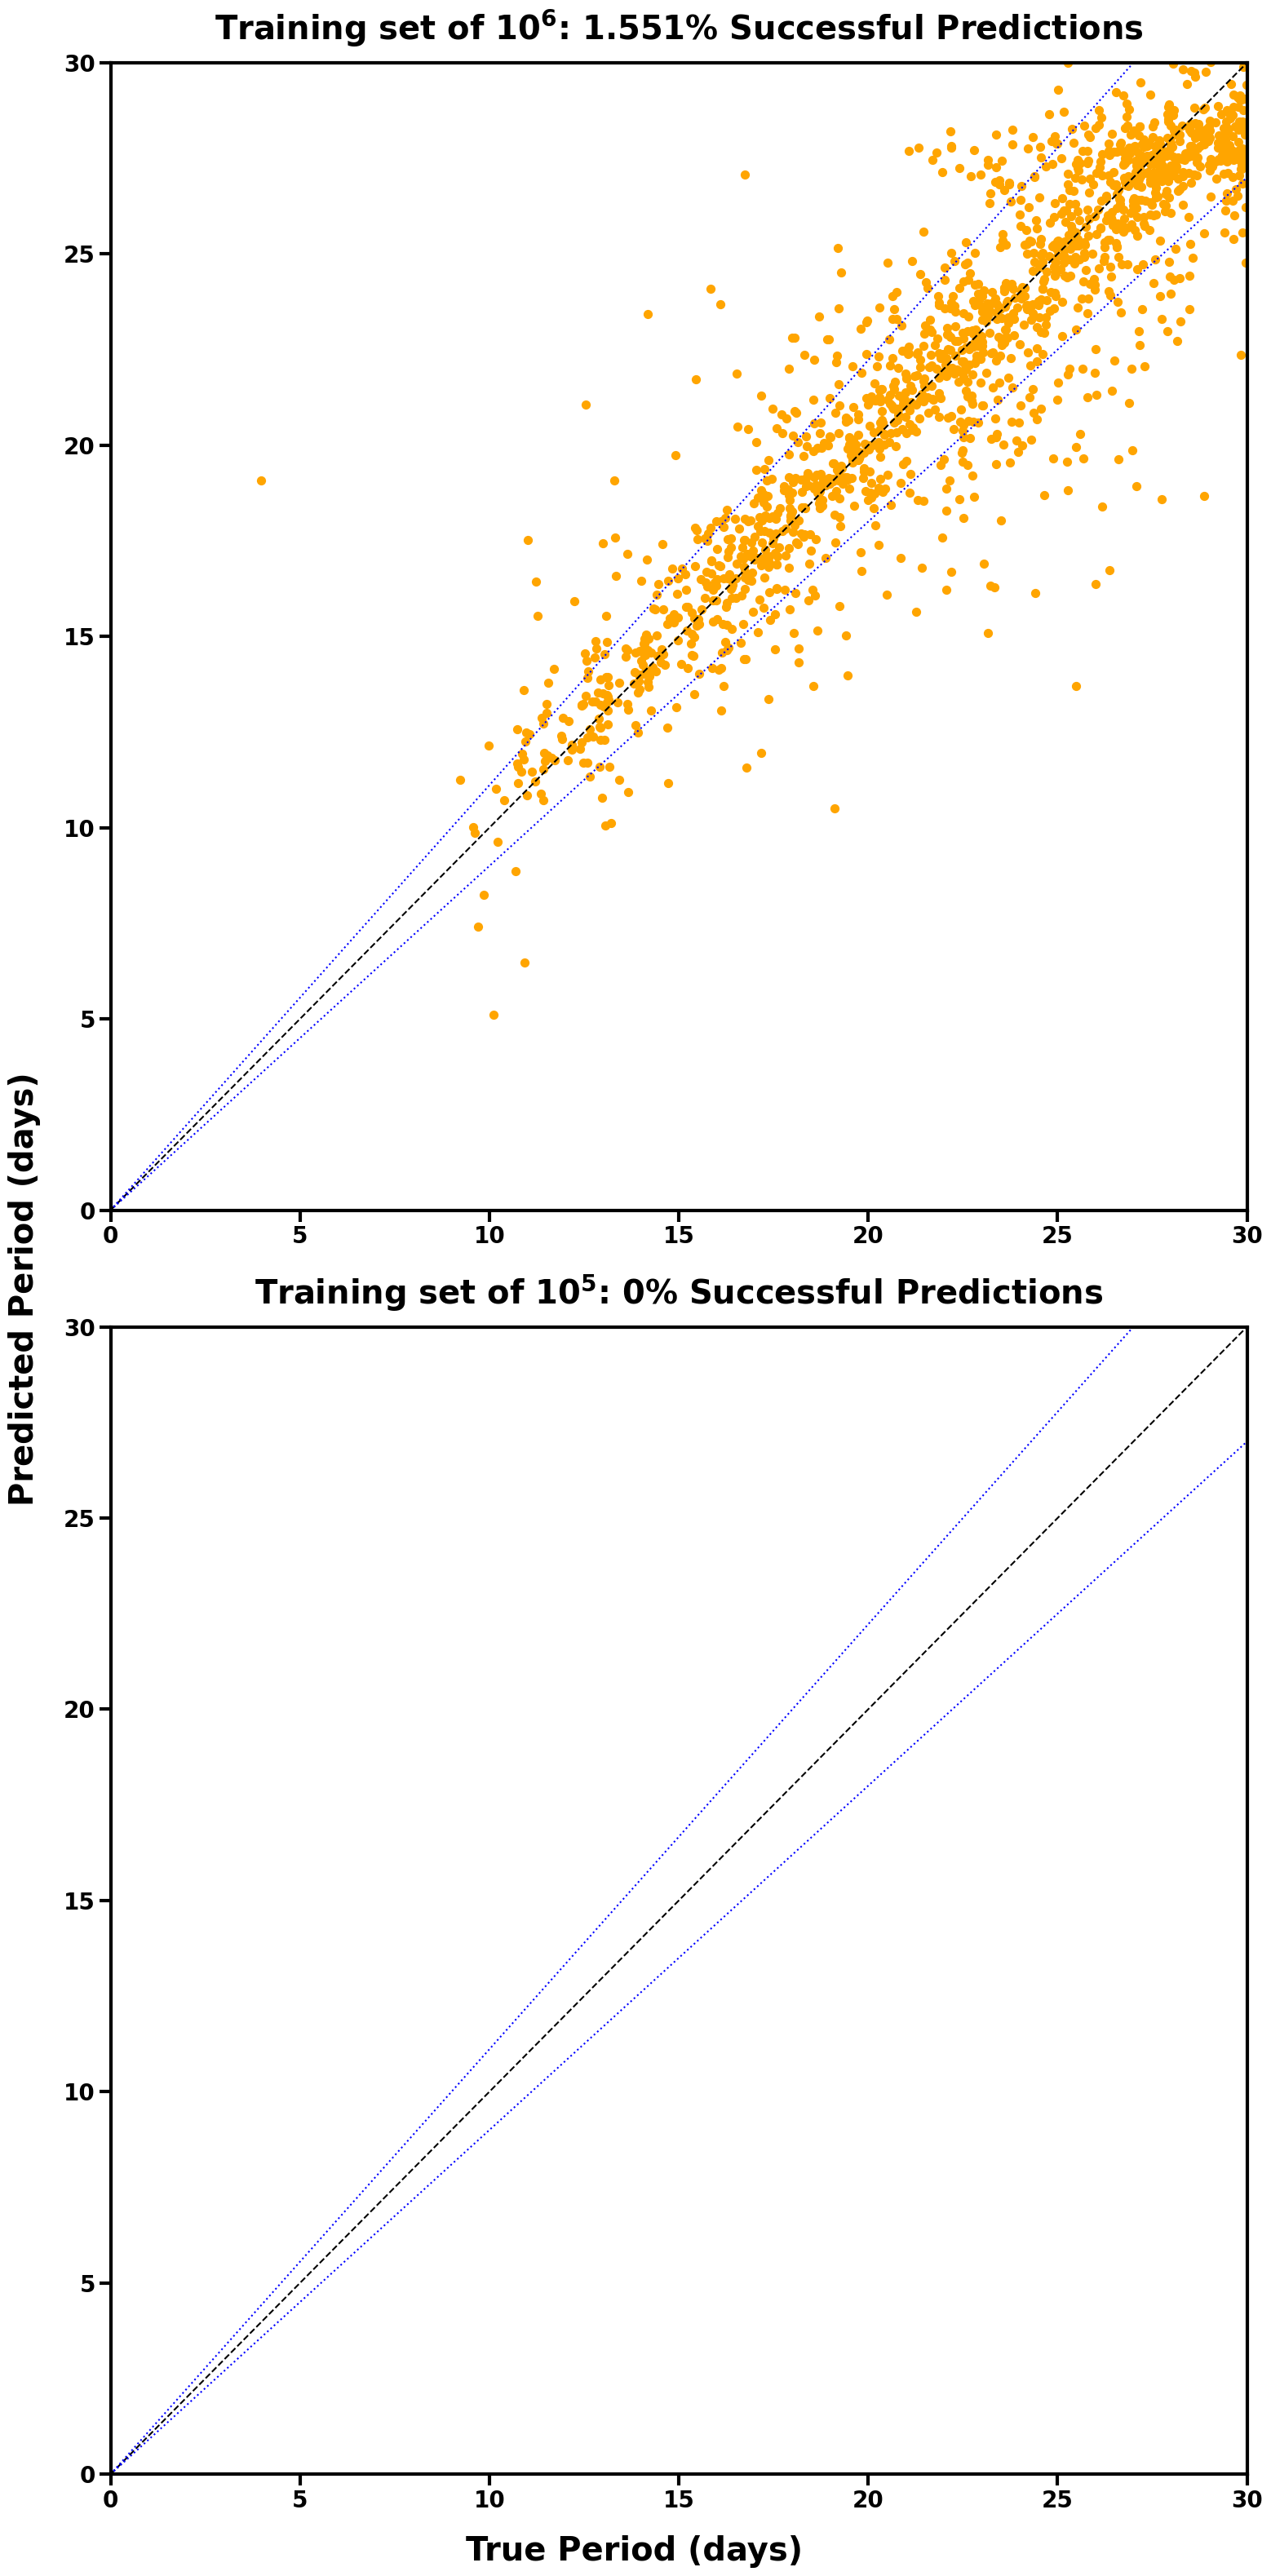

In [11]:
scatter_test_bothsamesize(table3_row2, table3_row3, "5.1")

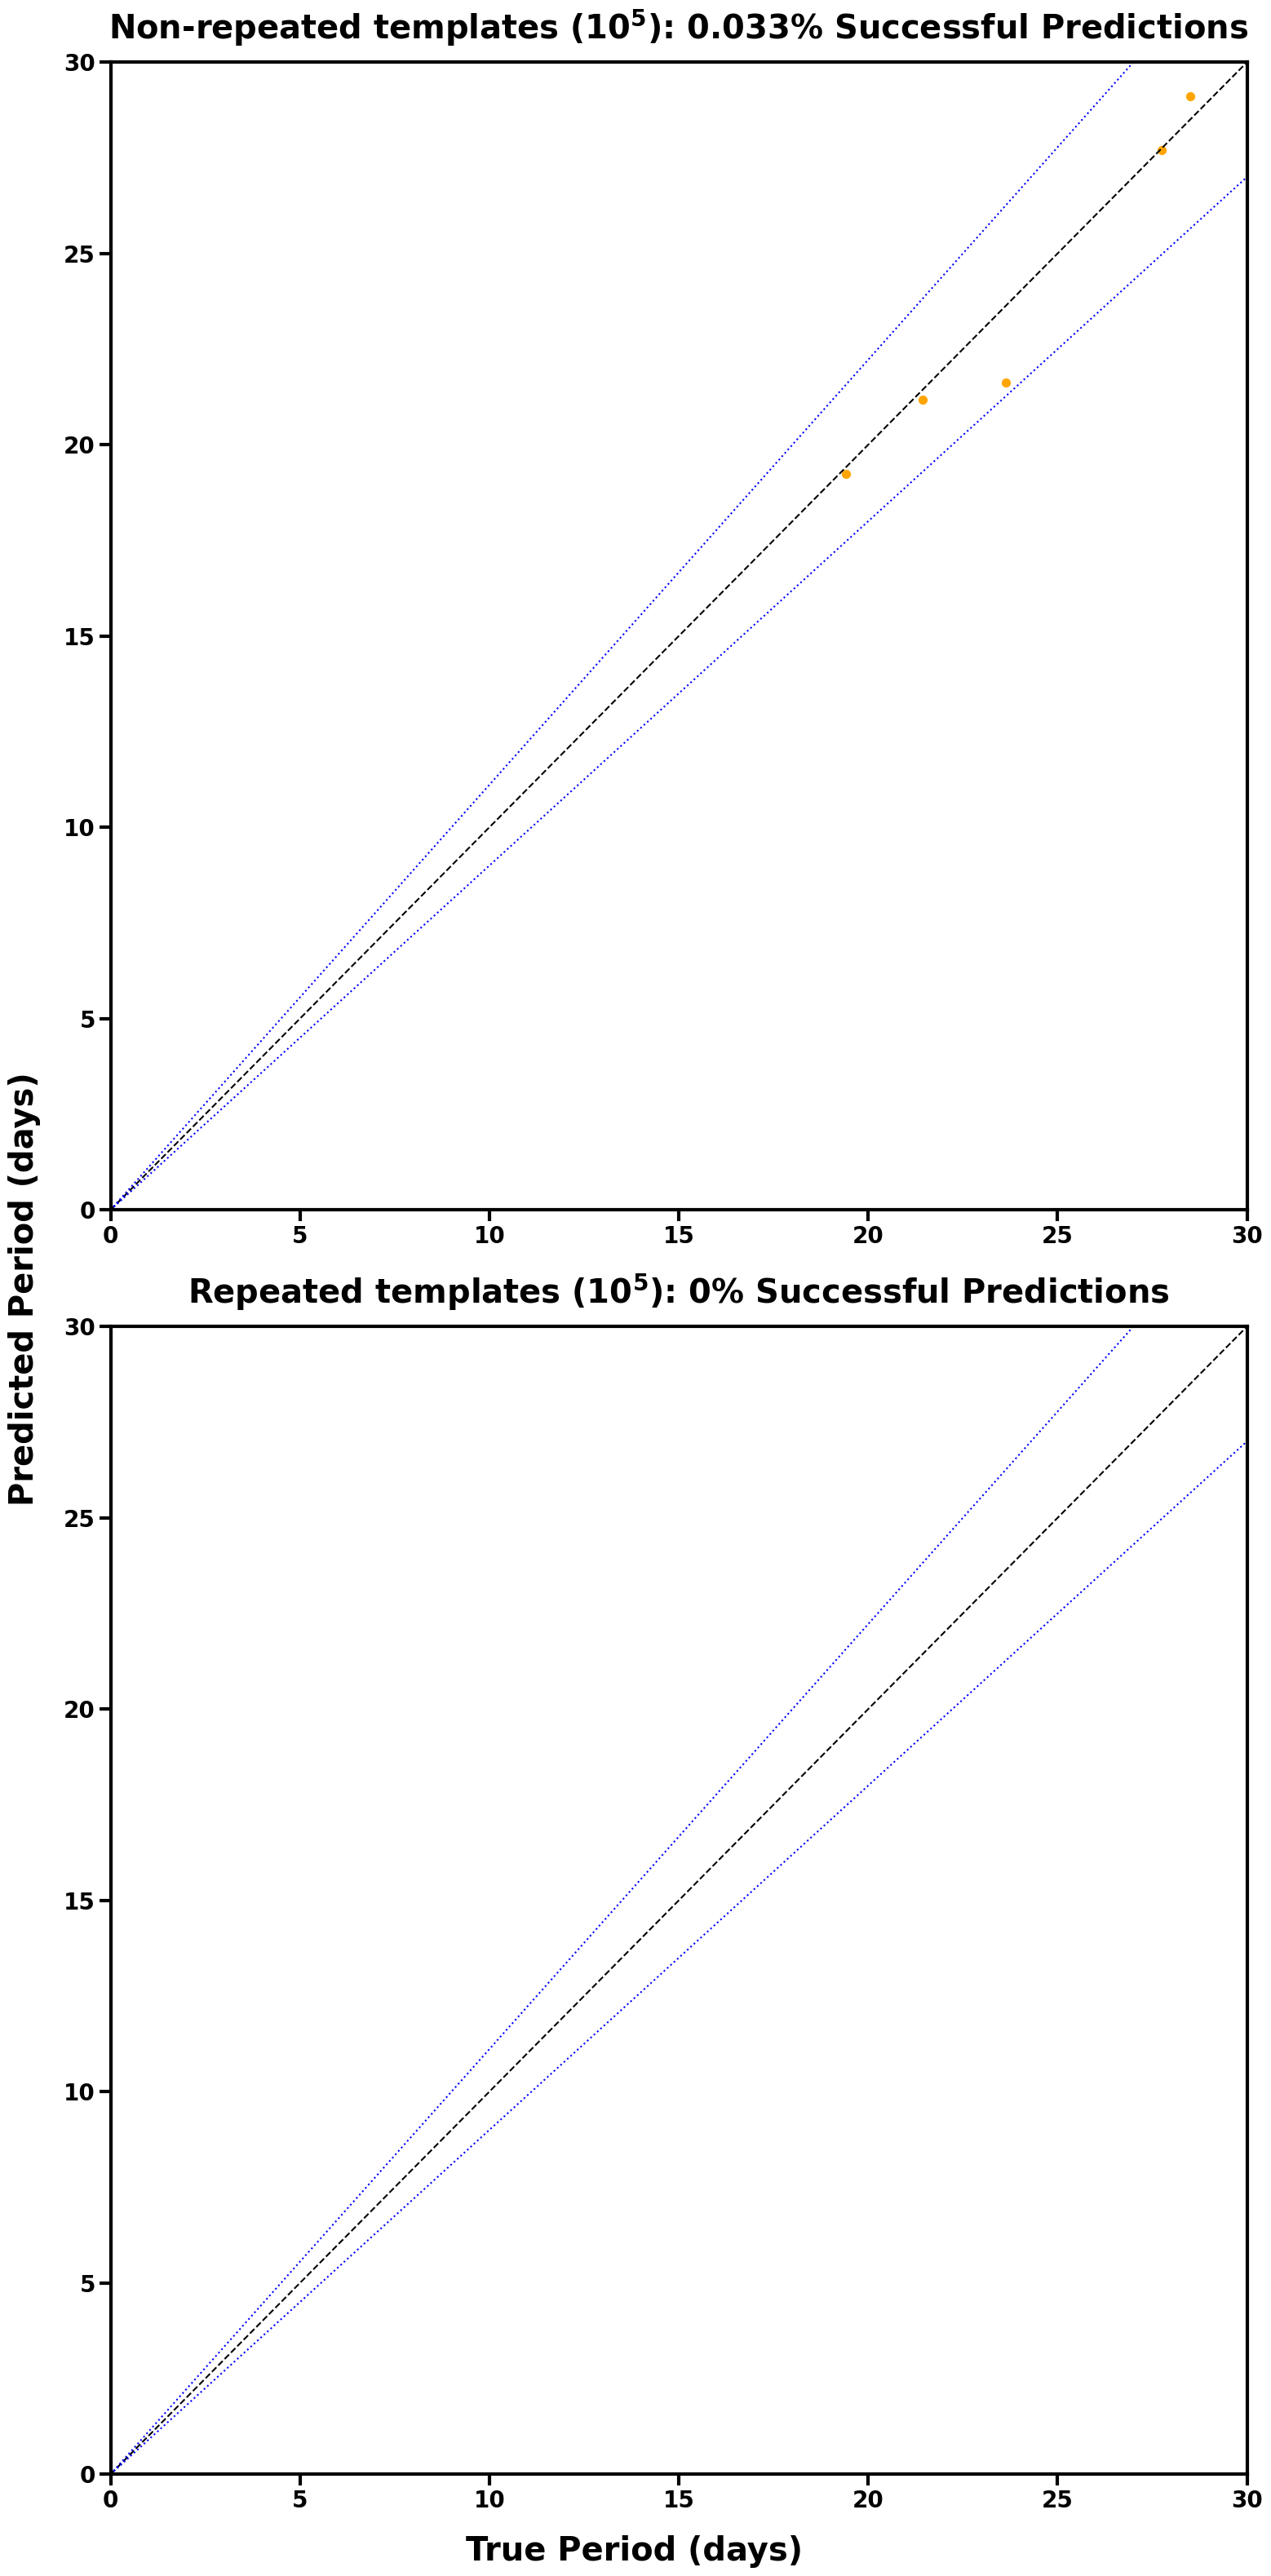

In [12]:
scatter_test_bothsamesize(table3_row4, table3_row3, "5.2")

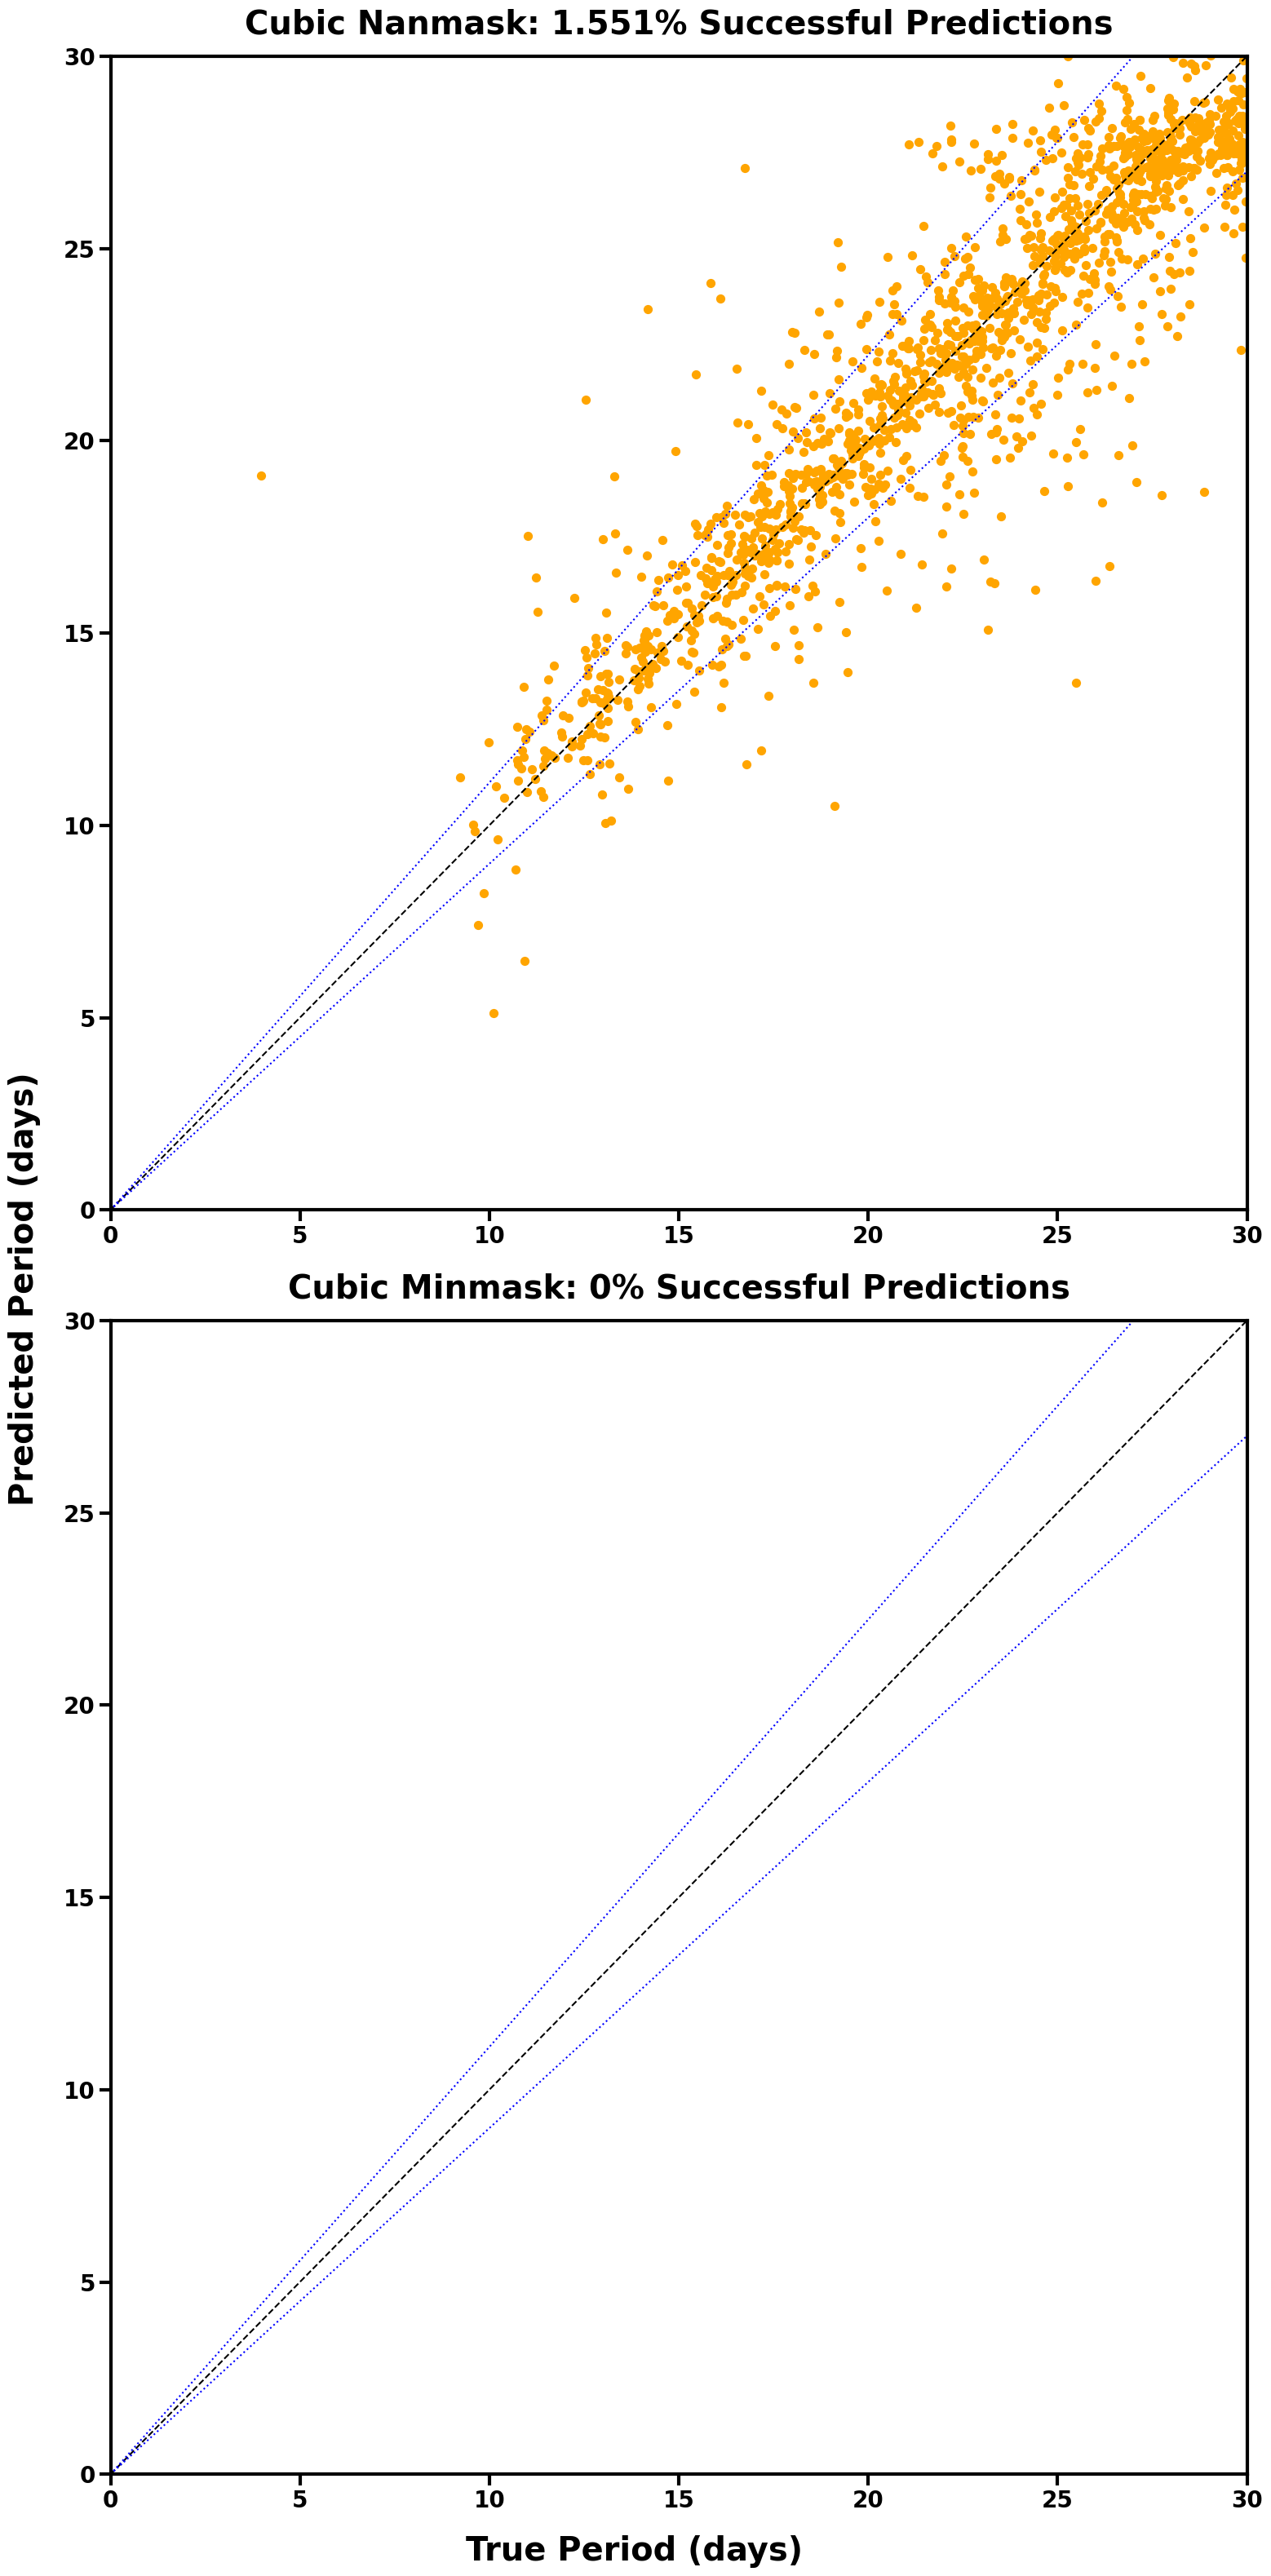

In [13]:
scatter_test_bothsamesize(table3_row2, table3_row5, "5.3")

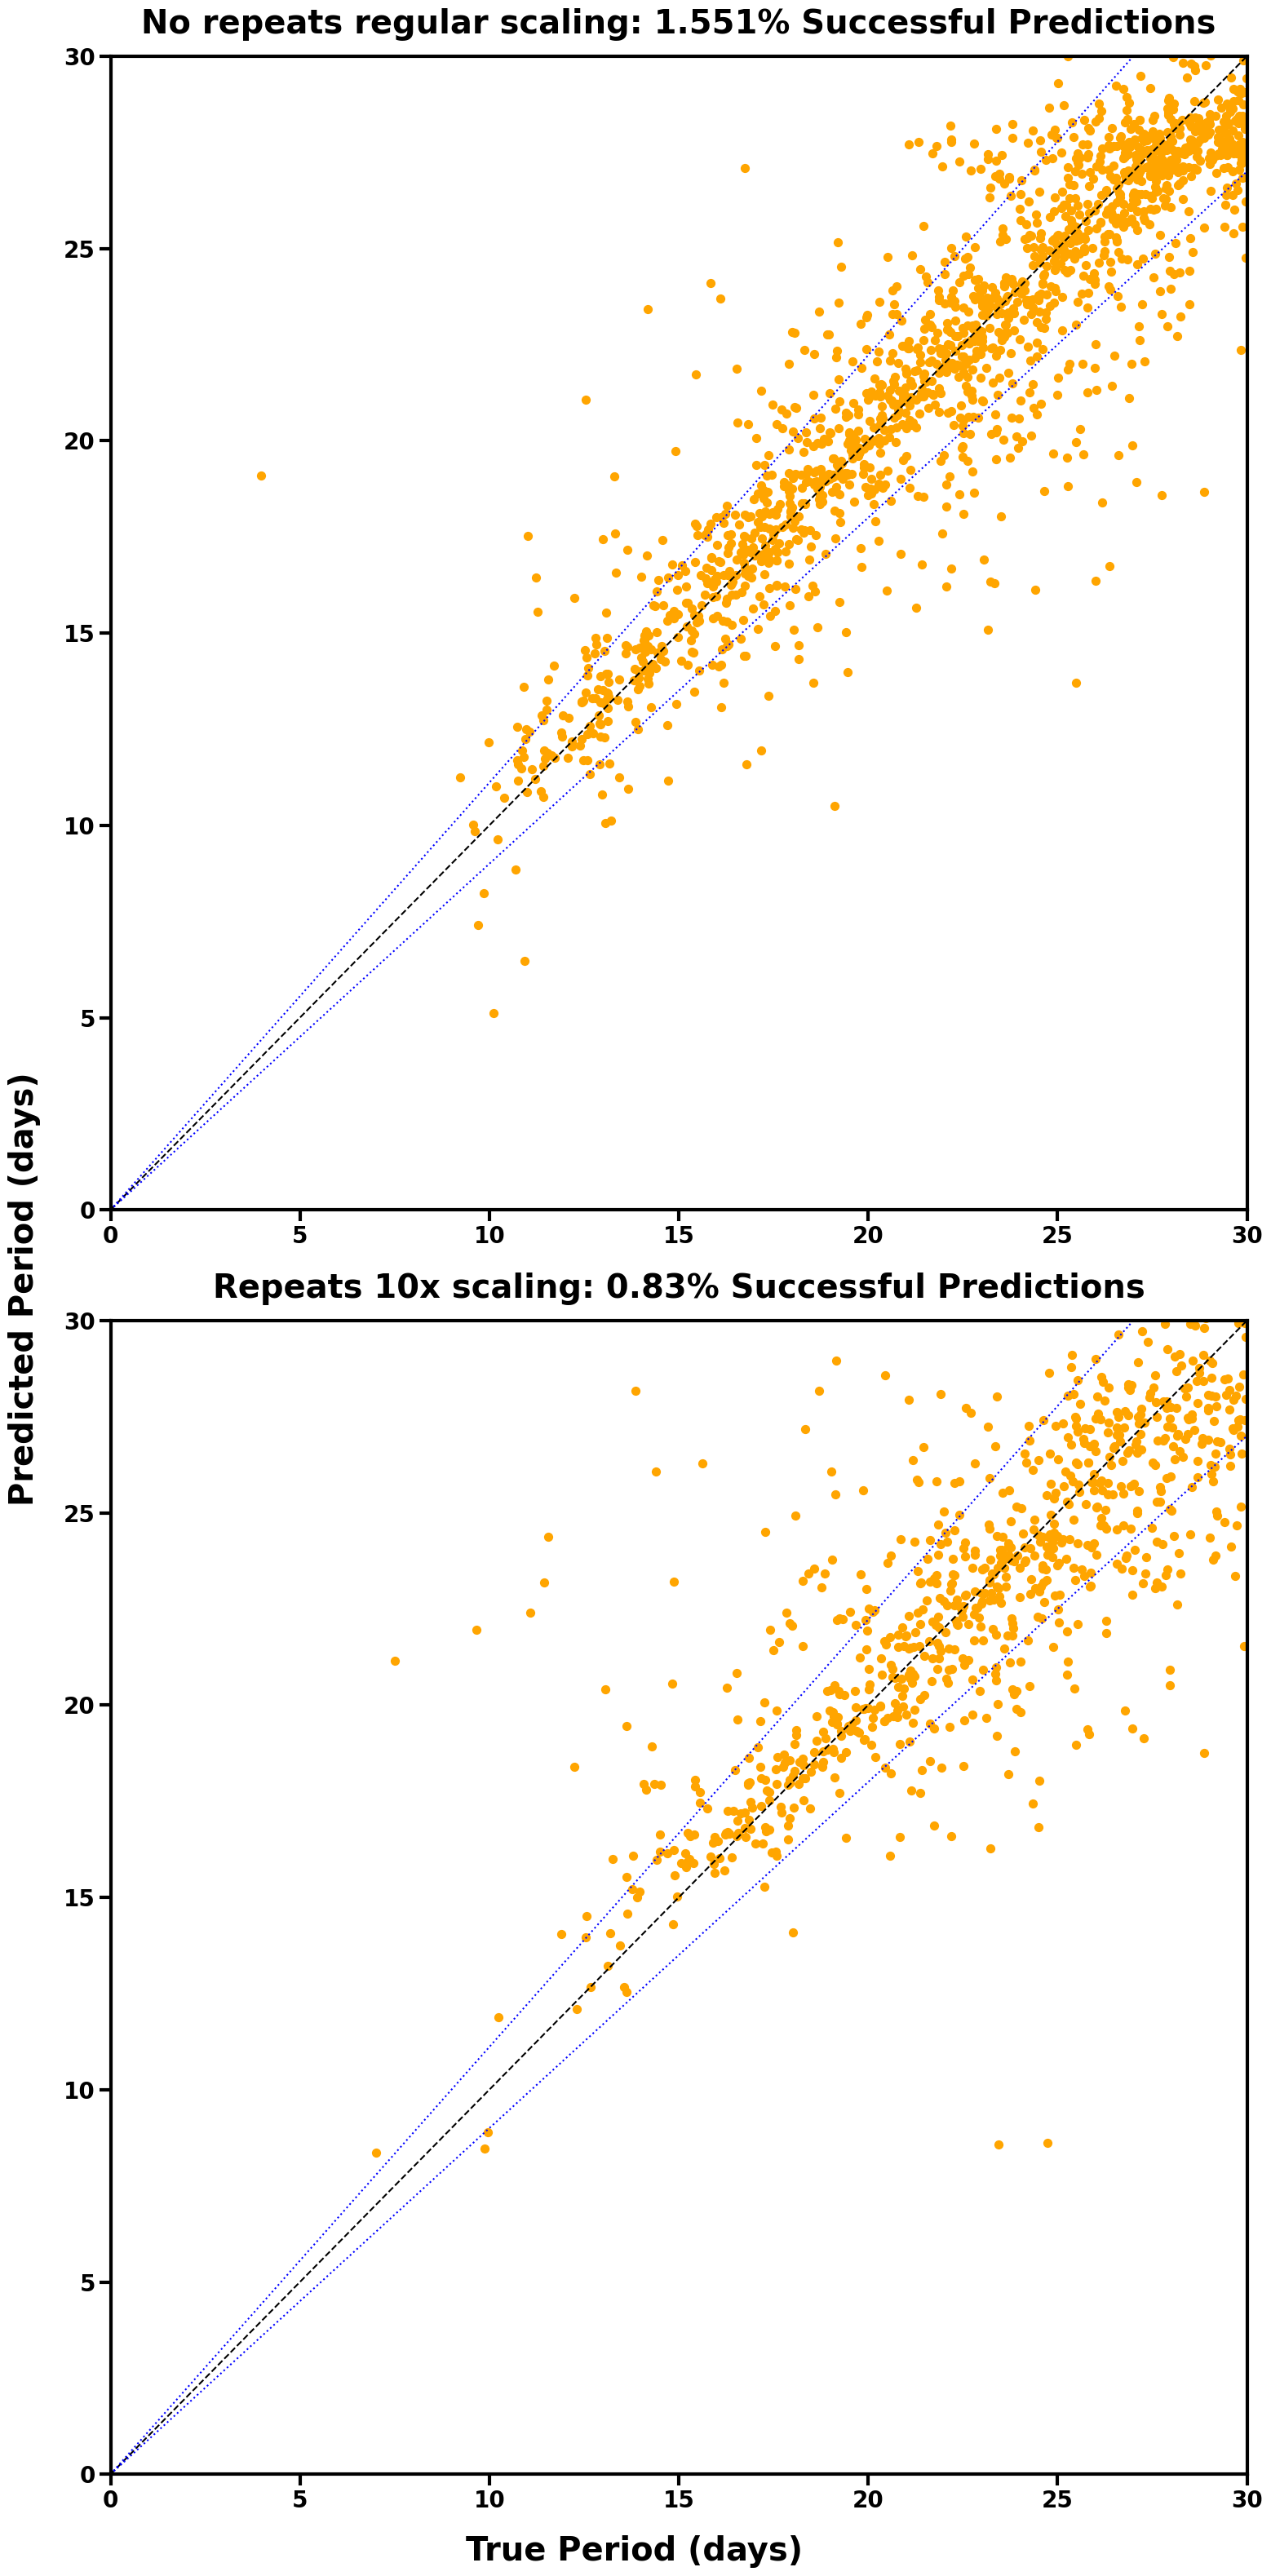

In [14]:
scatter_test_bothsamesize(table3_row2, table3_row6, "5.4")

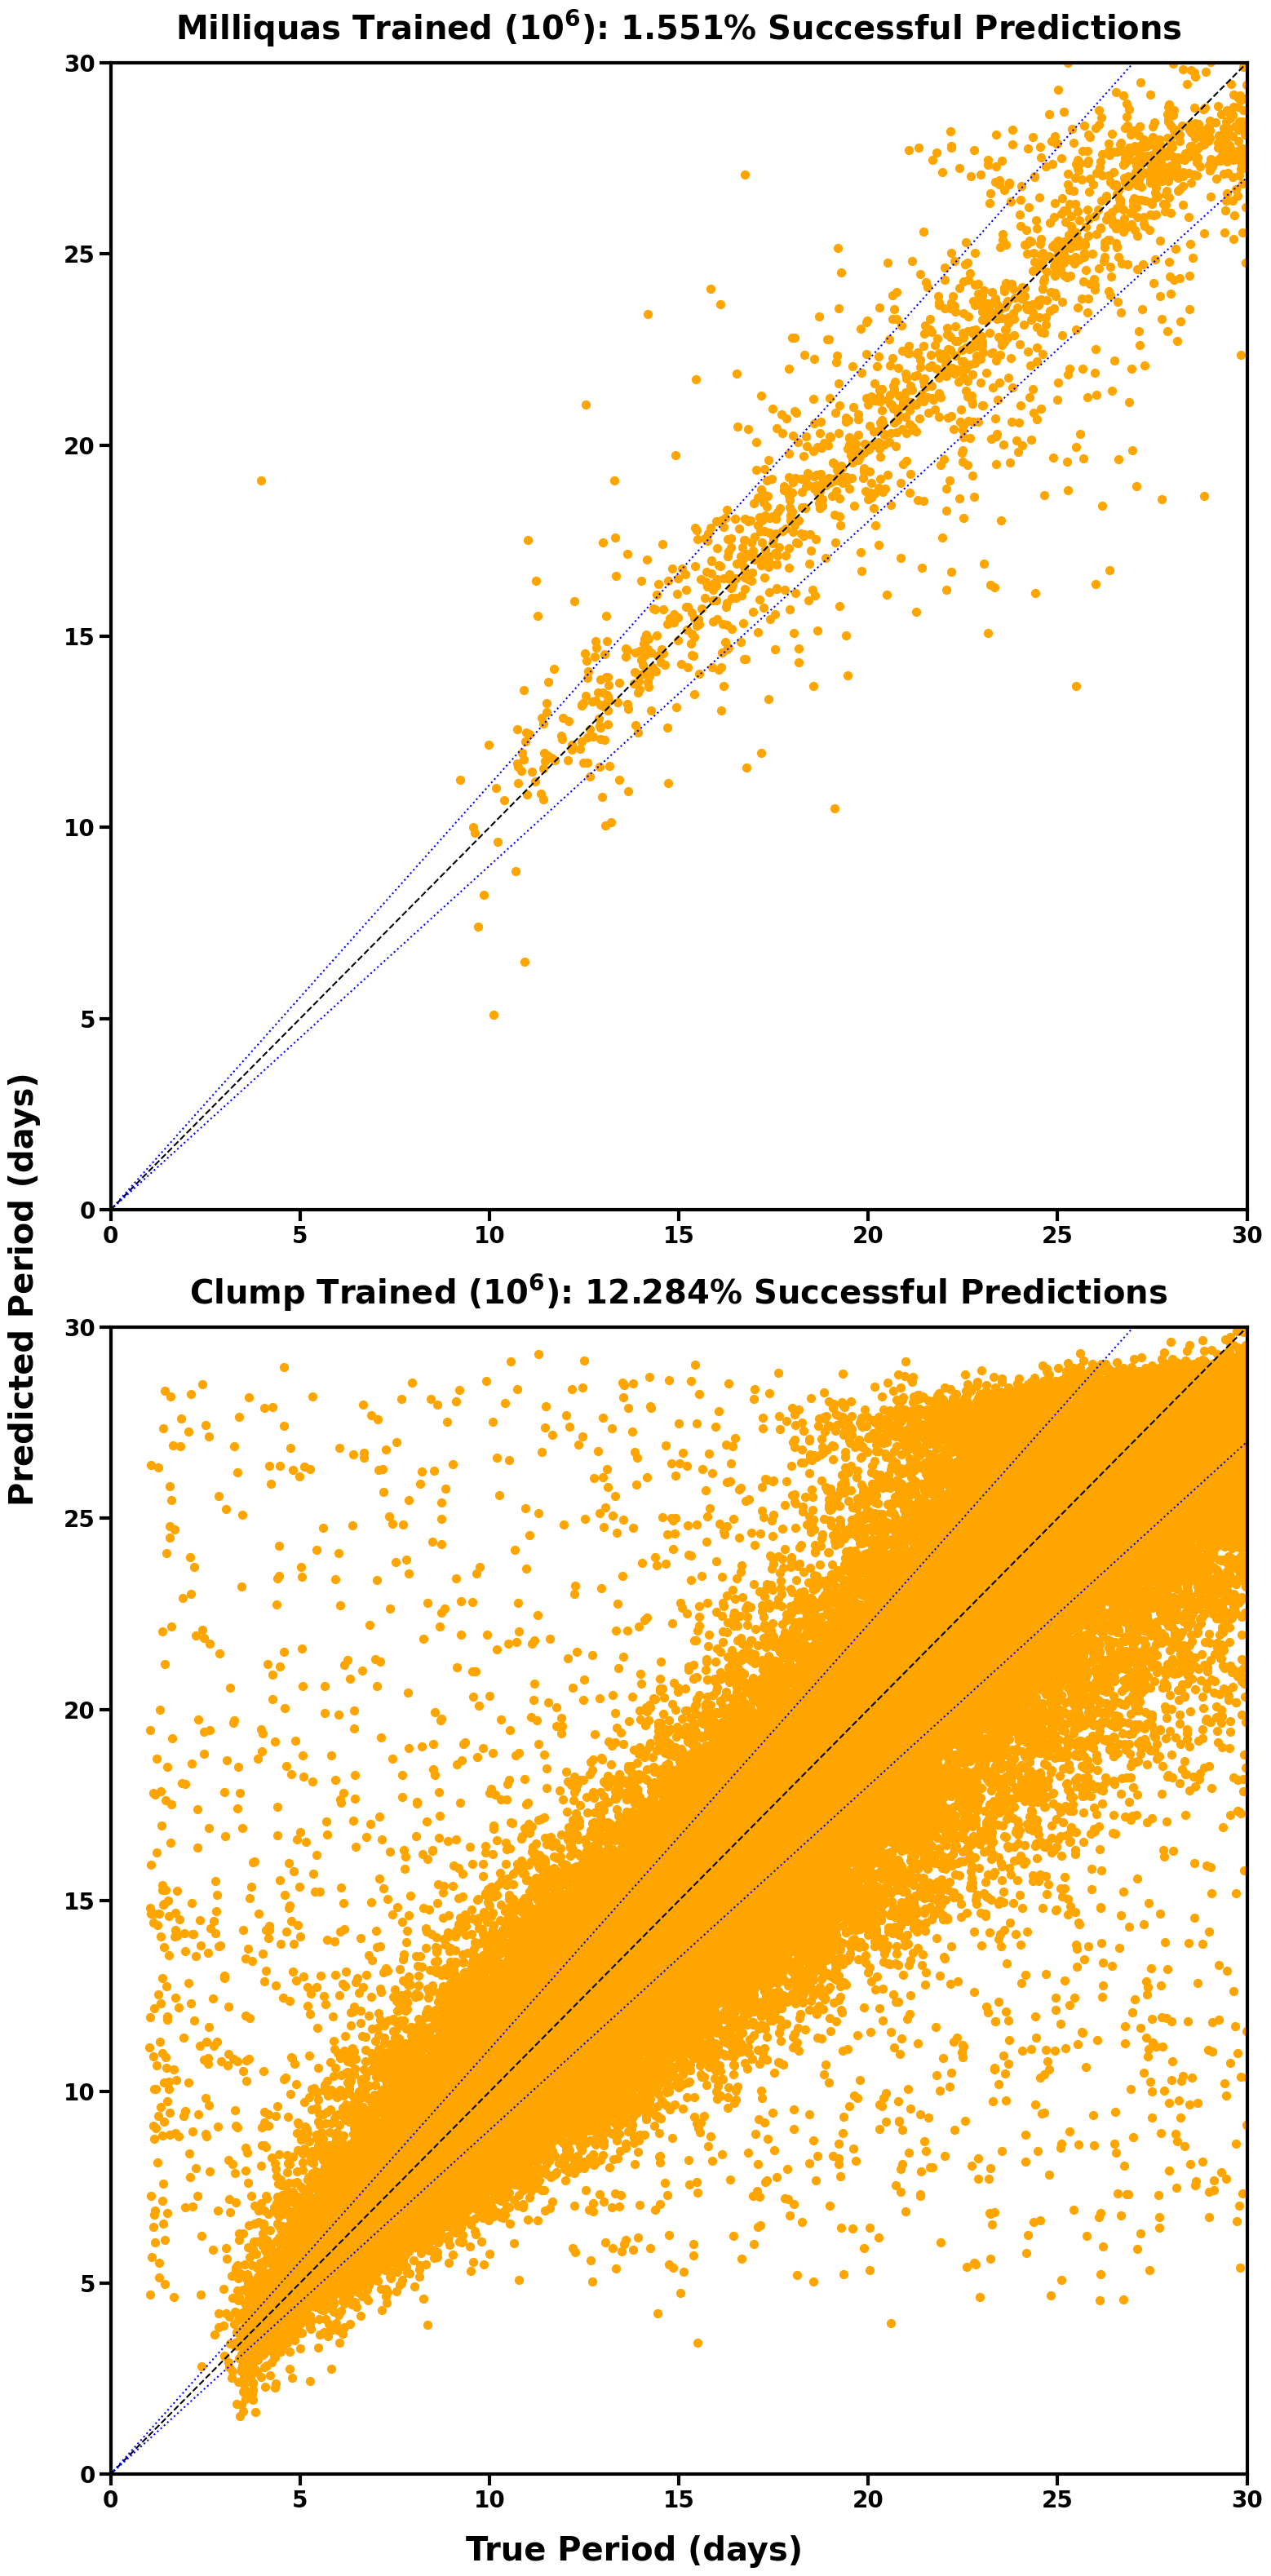

In [15]:
scatter_test_bothsamesize(table3_row2, table3_row1, "5.6")

## (old) four plots

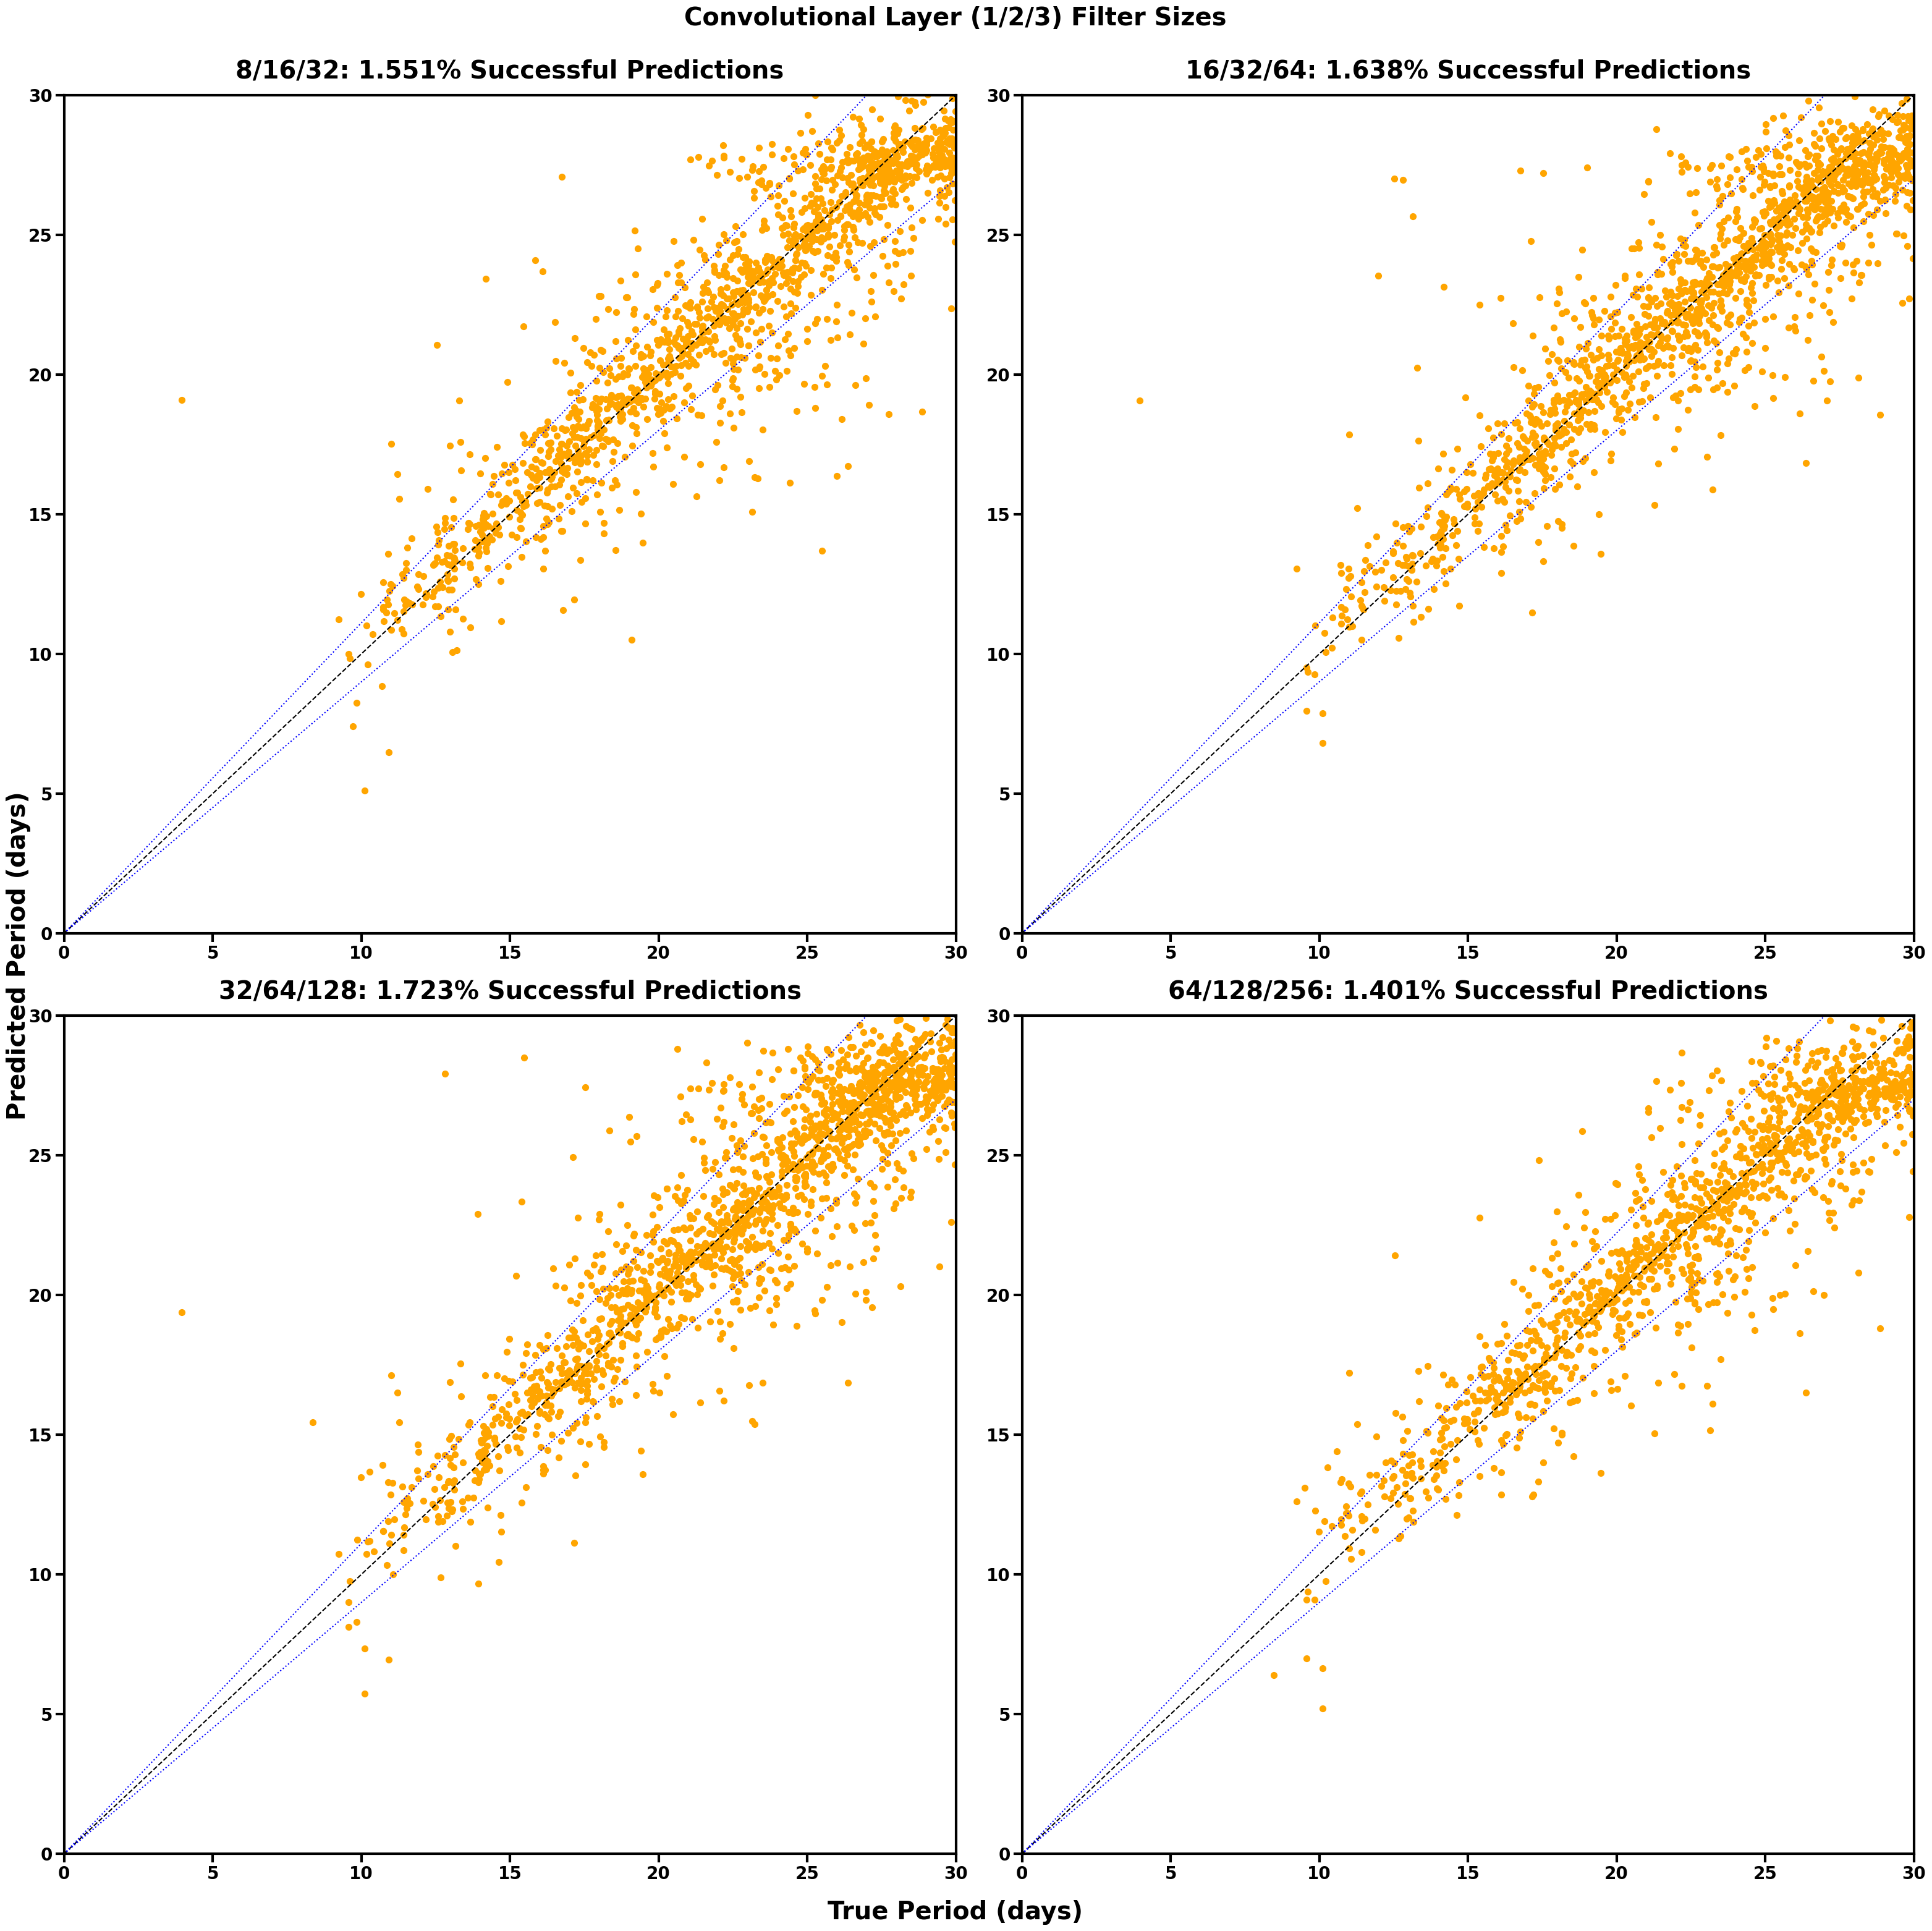

In [16]:
scatter_test_4(table3_row2, table3_row7, table3_row8, table3_row9, "5.5")

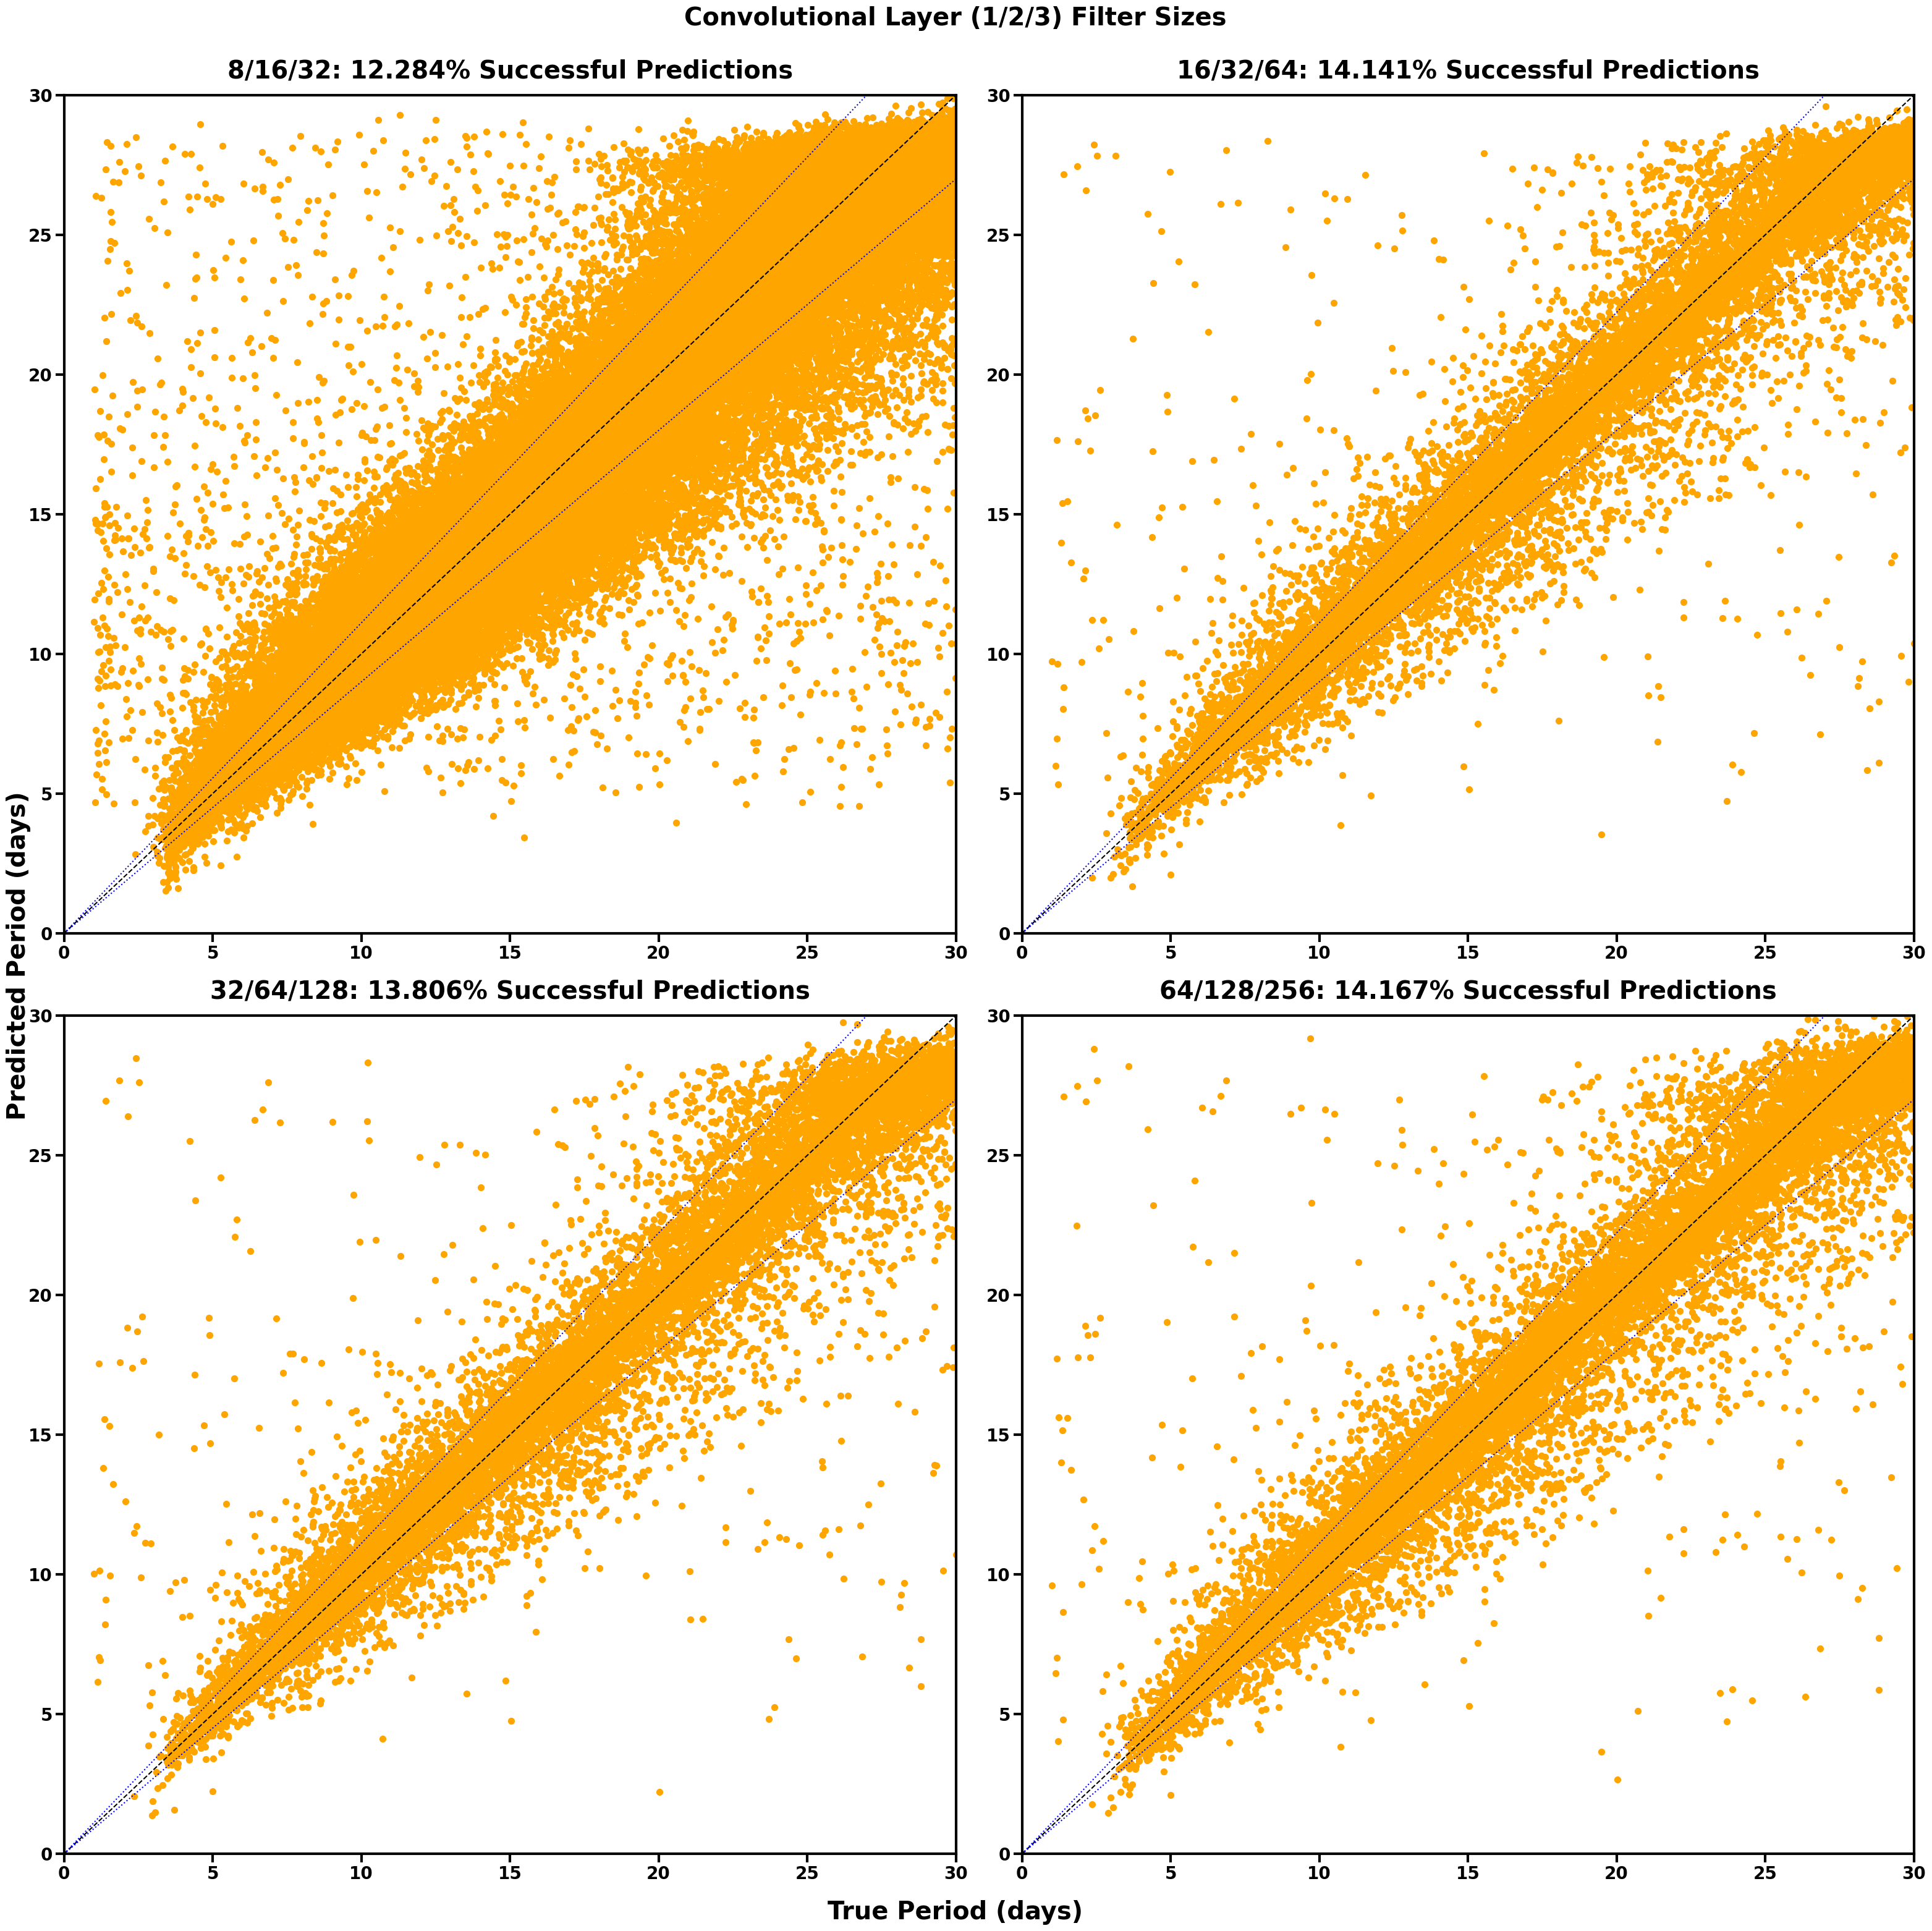

In [17]:
scatter_test_4(table3_row1, table3_row10, table3_row11, table3_row12, "5.6")